In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv('../../../Data/ushape.csv')

In [16]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   3.159499363321345566e-02  99 non-null     float64
 1   9.869877579082642072e-01  99 non-null     float64
 2   0.000000000000000000e+00  99 non-null     float64
dtypes: float64(3)
memory usage: 2.4 KB


In [18]:
df.rename(columns={'3.159499363321345566e-02': 'X'}, inplace=True)
df.rename(columns={'9.869877579082642072e-01': 'Y'}, inplace=True)
df.rename(columns={'0.000000000000000000e+00': 'class'}, inplace=True)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       99 non-null     float64
 1   Y       99 non-null     float64
 2   class   99 non-null     float64
dtypes: float64(3)
memory usage: 2.4 KB


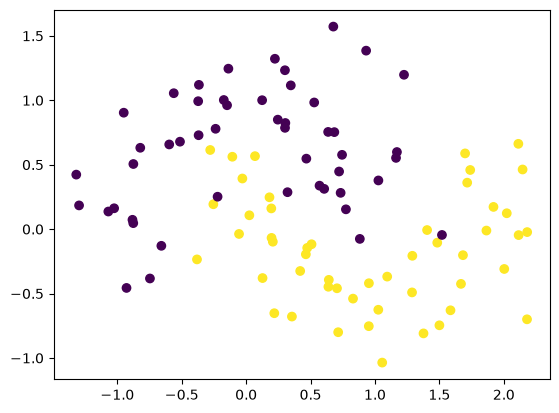

In [20]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [21]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [22]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Input

In [23]:
model = Sequential()

model.add(Input(shape=(2,)))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.get_weights()

[array([[-0.20118529,  0.4012609 ,  0.07224512,  0.6405131 , -0.5259625 ,
          0.27365828, -0.49622047,  0.22648454,  0.0787971 ,  0.21233666],
        [ 0.00680703,  0.6204975 ,  0.6502957 , -0.5228168 , -0.32187867,
          0.33937496,  0.42465085,  0.11707145,  0.2141043 , -0.2613076 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.30112332, -0.5172127 ,  0.14221644, -0.46639442,  0.42459315,
          0.28471124,  0.2312414 ,  0.2596693 ,  0.15913725, -0.46871364],
        [-0.35926482,  0.06308436,  0.08471036,  0.23069501,  0.5303494 ,
         -0.21516678, -0.02548176, -0.1058937 , -0.28715757, -0.03526211],
        [-0.34418434, -0.52185196, -0.32432804, -0.06728587, -0.15889737,
          0.42586392,  0.44821328,  0.49818492, -0.08021283,  0.47876692],
        [ 0.53011143, -0.4115367 , -0.31316924, -0.16899425, -0.00505292,
          0.14652216, -0.3037966 ,  0.0614593 ,  0.10151458, -0.02398694],
        [-0.37480

In [27]:
initial_weights = model.get_weights()

In [28]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [29]:
model.set_weights(initial_weights)

In [30]:
model.get_weights()

[array([[ 0.88673615,  0.15425873, -0.69041014, -0.4833303 ,  1.8351026 ,
          0.55442405, -1.3383105 , -1.1211292 ,  0.06194277,  0.5444087 ],
        [-0.02656765,  0.56357276, -0.08195753, -0.6719273 ,  0.41662905,
         -0.97523206, -0.91070014, -0.4637201 ,  0.17555827, -0.11786167]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.36413902,  0.27511546, -0.3041175 ,  0.29673237,  0.06948195,
         -0.02926718, -0.0147177 ,  0.05773543,  0.04126255, -0.18752353],
        [ 0.45134017,  0.08412808,  0.10679359, -0.05936691,  0.02672565,
          0.00943278, -0.15981348,  0.21036172,  0.31493428, -0.04547189],
        [-0.42071208,  0.13713194,  0.21763721,  0.0712272 , -0.12894048,
          0.09244747, -0.39934608,  0.51591414, -0.23289639, -0.07771397],
        [ 0.02859483, -0.02484884,  0.30550116, -0.09585247, -0.11672658,
          0.17604569,  0.5444038 , -0.06696886, -0.21106926, -0.0573251 ],
        [-0.30583

In [31]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [33]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.6203 - loss: 0.6312 - val_accuracy: 0.8000 - val_loss: 0.5586
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6329 - loss: 0.6206 - val_accuracy: 0.8000 - val_loss: 0.5473
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6203 - loss: 0.6101 - val_accuracy: 0.8500 - val_loss: 0.5381
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6203 - loss: 0.6004 - val_accuracy: 0.8000 - val_loss: 0.5292
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6582 - loss: 0.5896 - val_accuracy: 0.8000 - val_loss: 0.5186
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7089 - loss: 0.5796 - val_accuracy: 0.8500 - val_loss: 0.5083
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7342 - loss: 0.5688 - val_accuracy: 0.8500 - val_loss: 0.4982
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7722 - loss: 0.5577 - val_accuracy: 0.8500 - val_loss:

In [34]:
model.get_weights()

[array([[ 0.7814514 ,  0.05070094, -0.6779386 , -0.5288982 ,  1.9034545 ,
          0.57087594, -1.385762  , -1.2452871 , -0.05400179,  0.5450887 ],
        [-0.10722101,  0.63385844, -0.04981452, -0.65543884,  0.36081758,
         -1.052253  , -0.9428873 , -0.34877738,  0.25166646, -0.20621003]],
       dtype=float32),
 array([ 0.11250353, -0.02168255, -0.10367141, -0.14204119, -0.31630713,
        -0.05581691, -0.22422694,  0.18447882, -0.03095982,  0.0160061 ],
       dtype=float32),
 array([[ 0.32183552,  0.21157014, -0.24858575,  0.328113  ,  0.07790605,
          0.05467677, -0.05077131,  0.0207713 ,  0.10376909, -0.21779445],
        [ 0.52551854,  0.10643385,  0.11174864, -0.1558763 , -0.04751278,
         -0.03546571, -0.17352137,  0.27334666,  0.23020248,  0.02031727],
        [-0.3771787 ,  0.2115052 ,  0.17045464,  0.05097955, -0.13991301,
         -0.00430204, -0.28304905,  0.5647253 , -0.29875007, -0.03534975],
        [-0.01793745,  0.04213012,  0.29707384, -0.01678645, 

<Axes: >

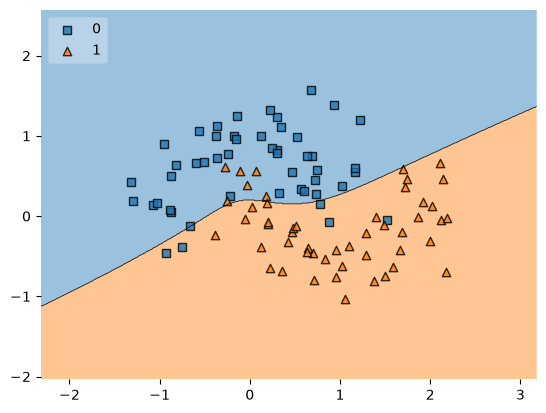

In [36]:
from mlxtend.plotting import plot_decision_regions

class KerasBinaryClassifier:
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        probabilities = self.model.predict(X, verbose=0)
        return (probabilities.ravel() >= self.threshold).astype(int)

plot_decision_regions(X, y.astype(int), clf=KerasBinaryClassifier(model), legend=2)